# ArtBench-10

This notebook was firstly a template for class projects using **ArtBench-10**, provided by the teachers.

It already covered:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `../data/` (local folder with ArtBench-10 data)


In [48]:
from __future__ import annotations

import sys
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [49]:
import torch
import torchvision
from torchvision import transforms as T

print(torchvision.__version__)
print(hasattr(T, "Resize"))

0.26.0+cu130
True


In [50]:
import torch

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponível: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [51]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from notebooks/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'src'
DATASET_ROOT = PROJECT_ROOT / 'data'

if not DATASET_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from notebooks/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT   =', PROJECT_ROOT)
print('DATASET_ROOT   =', DATASET_ROOT)

PROJECT_ROOT   = ..
DATASET_ROOT   = ../data


In [52]:
# Load ArtBench-10 from local dataset folder
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(DATASET_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../data'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']



Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


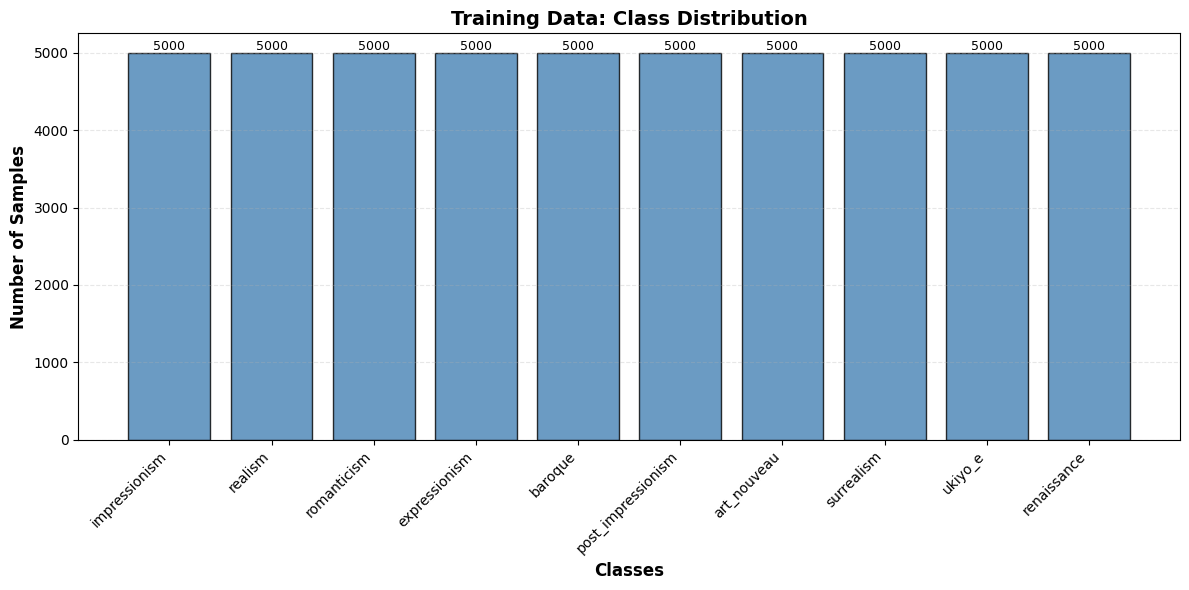

In [53]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 6))
counts = [train_counts.get(cid, 0) for cid in range(num_classes)]
bars = ax.bar(range(num_classes), counts, color='steelblue', alpha=0.8, edgecolor='black')

# Customize the plot
ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Training Data: Class Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

**Important Note:** This creates `train_loader` which contains **100% of the training dataset**. 
This dataloader is used in **Phase 2** (final training). For quick development in **Phase 1**, use `train_loader_from_csv` (created in the next section) which contains only **20% of samples**.

In [54]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
]) 

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

# PHASE 2: Full training dataset (100% of train split)
# Use this dataloader for final model training after selecting the best architecture
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

**PHASE 1 DATALOADER**: This creates `train_loader_from_csv` which contains **exactly 20% of training samples**. Use this for rapid iteration on hyperparameters and model architecture selection. Training is ~3x faster than full dataset.

You can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.

In [55]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('../data/training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# PHASE 1: Fast development with 20% subset
# Use this dataloader to quickly iterate on hyperparameters and model selection
# Dataset is loaded from training_20_percent.csv which contains exactly 20% of training samples
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))

Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

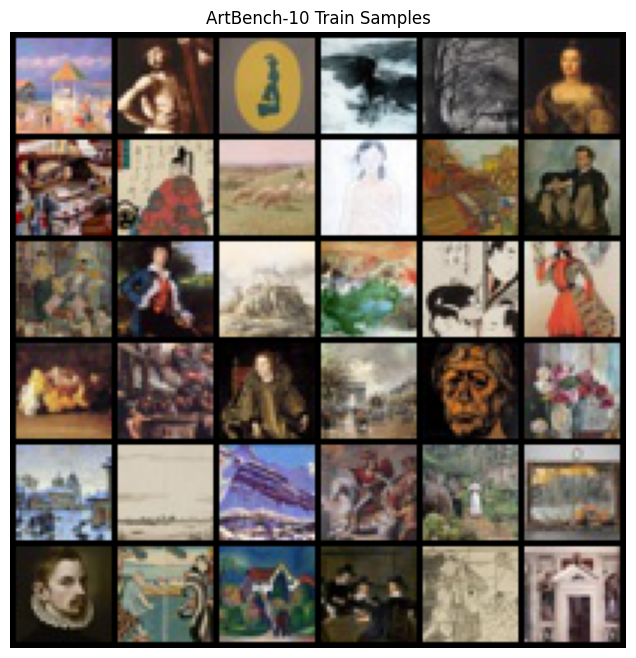

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [56]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    x_vis = ((x + 1.0) / 2.0)
    grid = make_grid(x_vis, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)

show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')


## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [57]:
"""

import csv

def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name

            # Keep tensors in [-1,1] everywhere; convert only when saving.
            x_to_save = ((x[i] + 1.0) / 2.0).clamp(0, 1)
            save_image(x_to_save, path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)

"""

'\n\nimport csv\n\ndef export_split_to_folder(\n    loader: DataLoader,\n    class_names: list[str],\n    out_dir: Path,\n    max_images: int | None = 500,\n):\n    out_dir = Path(out_dir)\n    img_dir = out_dir / \'images\'\n    img_dir.mkdir(parents=True, exist_ok=True)\n\n    rows = []\n    saved = 0\n\n    for x, y, idx in loader:\n        b = x.shape[0]\n        for i in range(b):\n            if max_images is not None and saved >= max_images:\n                break\n\n            label_id = int(y[i].item())\n            label_name = class_names[label_id]\n            src_idx = int(idx[i].item())\n\n            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"\n            path = img_dir / file_name\n\n            # Keep tensors in [-1,1] everywhere; convert only when saving.\n            x_to_save = ((x[i] + 1.0) / 2.0).clamp(0, 1)\n            save_image(x_to_save, path)\n\n            rows.append({\n                \'file_name\': file_name,\n              

---

# 1. Implement and Train Generative Models

## Overview
This section implements four generative model families for comparison:
1. **VAE** (Variational Autoencoder) - Probabilistic autoencoder
2. **DCGAN** (Deep Convolutional GAN) - Adversarial network
3. **WGAN-GP** (Wasserstein GAN with Gradient Penalty) - Adversarial network
3. **Diffusion Model** - Denoising probabilistic model

**Development Strategy:**
- **Phase 1 (Development)**: Train and evaluate on 20% subset using `train_loader_from_csv`
- **Phase 2 (Production)**: Retrain best model on 100% dataset using `train_loader` with ≥10 random seeds
- **Metrics**: FID (quality/diversity) and KID (statistical robustness)

**Key Decision:** After Phase 1, we selected the best architecture based on FID score and training stability, then retrained in Phase 2 on full dataset.

In [58]:
# Additional imports for generative models and evaluation
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import torch.nn.functional as F

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


---
## 1.1: VAE (Variational Autoencoder)
**What it does:**
- Encoder: Compresses 32×32 image → latent distribution (μ, σ)
- Reparameterization: Sample z ~ N(μ, σ)
- Decoder: Reconstructs image from z
- Loss: Reconstruction (MSE) + KL divergence

**Key advantages:** Stable training, interpretable latent space, good baseline

**Key trade-offs:** Potentially blurry images compared to GANs

In [59]:
class VAEEncoder(nn.Module):
    """VAE Encoder: 32×32 image → latent distribution (μ, log-var)
    
    Improvements over baseline:
    - Wider channels (64 → 128 → 256) for richer feature maps
    - GroupNorm for stable training (independent of batch size)
    - LeakyReLU to avoid dead neurons
    """
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, stride=2, padding=1),    # 32→16
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),             # 16→8
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),            # 8→4
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)


class VAEDecoder(nn.Module):
    """VAE Decoder: latent sample → 32×32 image

    Improvements:
    - Upsample + Conv instead of ConvTranspose2d to eliminate checkerboard artifacts
    - GroupNorm + ReLU for stable training
    - Matching wider channels (256 → 128 → 64 → 3)
    """
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            # 4→8
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
            # 8→16
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
            # 16→32
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, img_channels, 3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 256, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    """Variational Autoencoder"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim, img_channels)
        self.decoder = VAEDecoder(latent_dim, img_channels)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        """Sample z = μ + σ·ε  (reparameterization trick)"""
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def sample(self, num_samples, temperature=1.0):
        z = torch.randn(num_samples, self.latent_dim,device=next(self.parameters()).device) * temperature
        return self.decoder(z)

def vae_loss(recon, x, mu, logvar, beta=0.5, recon_type='l1', free_bits=0.5):
    # Reconstruction
    if recon_type == 'l1':
        recon_loss = nn.functional.l1_loss(recon, x, reduction='mean')
    else:
        recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')

    # KL with free bits
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = torch.clamp(kl, min=free_bits)
    kl_loss = torch.mean(kl)

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✓ VAE defined")

✓ VAE defined


---
## 1.1.1: cVAE (Conditional Variational Autoencoder)
**What it does:**
- Encoder: Compresses 32x32 image together with class label -> latent distribution (mu, sigma)
- Reparameterization: Sample z ~ N(mu, sigma)
- Decoder: Reconstructs image conditioned on both z and the class label
- Loss: Reconstruction (L1 by default; MSE optional) + KL divergence

**Key advantages:** Controlled generation by class; usually better class consistency than vanilla VAE

**Key trade-offs:** Slightly more complex than vanilla VAE; quality still depends on latent bottleneck size

In [60]:
class CVAEEncoder(nn.Module):
    """Conditional VAE Encoder: 32x32 image + label → latent (mu, logvar)"""
    def __init__(self, latent_dim=128, img_channels=3, num_classes=10, embed_dim=32):
        super().__init__()
        # Embedding para a condição
        self.label_embed = nn.Embedding(num_classes, embed_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels + embed_dim, 64, 4, stride=2, padding=1),  # 32->16
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 16->8
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 8->4
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x, labels):
        # labels → embedding → expand para imagem
        label_emb = self.label_embed(labels)  # (B, embed_dim)
        label_emb = label_emb.view(label_emb.size(0), label_emb.size(1), 1, 1)
        label_emb = label_emb.expand(-1, -1, x.size(2), x.size(3))  # (B, embed_dim, H, W)
        x_cond = torch.cat([x, label_emb], dim=1)  # concat no canal
        h = self.conv(x_cond).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class CVAEDecoder(nn.Module):
    """Conditional VAE Decoder: latent + label → 32x32 image"""
    def __init__(self, latent_dim=128, img_channels=3, num_classes=10, embed_dim=32):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, embed_dim)
        self.fc = nn.Linear(latent_dim + embed_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            # 4->8
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
            # 8->16
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
            # 16->32
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, img_channels, 3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        # labels → embedding
        label_emb = self.label_embed(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        h = self.fc(z_cond).view(z_cond.size(0), 256, 4, 4)
        return self.deconv(h)

class CVAE(nn.Module):
    """Conditional Variational Autoencoder"""
    def __init__(self, latent_dim=128, img_channels=3, num_classes=10, embed_dim=32):
        super().__init__()
        self.encoder = CVAEEncoder(latent_dim, img_channels, num_classes, embed_dim)
        self.decoder = CVAEDecoder(latent_dim, img_channels, num_classes, embed_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        """Sample z = μ + σ·ε  (reparameterization trick)"""
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x, labels):
        mu, logvar = self.encoder(x, labels)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z, labels), mu, logvar

    def sample(self, num_samples, labels=None, temperature=1.0):
        """Generate new conditional samples"""
        if labels is None:
            labels = torch.randint(0, self.decoder.label_embed.num_embeddings, (num_samples,), device=next(self.parameters()).device)
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device) * temperature
        return self.decoder(z, labels)
    
def cvae_loss(recon, x, mu, logvar, beta=0.5, recon_type='l1', free_bits=0.5):
    """ELBO loss para cVAE com free bits, igual ao VAE que funcionou bem."""
    # Reconstruction loss
    if recon_type == 'l1':
        recon_loss = nn.functional.l1_loss(recon, x, reduction='mean')
    else:
        recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')

    # KL com free bits
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = torch.clamp(kl, min=free_bits)  # impede collapse
    kl_loss = torch.mean(kl)

    return recon_loss + beta * kl_loss, recon_loss, kl_loss


print("✓ cVAE defined")

✓ cVAE defined


---
## 1.2: DCGAN (Deep Convolutional GAN)
**What it does:**
- Generator: Noise → 32×32 realistic images  
- Discriminator: Image → probability "real or fake"
- Adversarial training: Generator fools discriminator, discriminator gets better
- Use batch normalization for stability

**Key advantages:** Sharp, high-quality images; well-studied architecture

**Key trade-offs:** Can have mode collapse; less diverse samples than VAE

In [61]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=128, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

print("✓ DCGAN (alternative) defined")


✓ DCGAN (alternative) defined


---
## 1.2.1: WGAN-GP (Wasserstein GAN with Gradient Penalty)
**What it does:**
- Generator: Noise → 32×32 realistic images
- Critic (Discriminator): Image → unbounded real-valued score (not probability)
- Wasserstein loss: Simpler training objective than BCE
- Gradient Penalty: Enforces 1-Lipschitz constraint on critic

**Key advantages:** More stable training than vanilla GAN; prevents mode collapse better

**Key trade-offs:** Requires gradient penalty computation; slower training than DCGAN

In [62]:
class WGANGPGenerator(nn.Module):
    """WGAN-GP Generator: noise → 32×32 images in [-1,1]"""
    def __init__(self, latent_dim, img_channels):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, img_channels, 3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )
    
    def forward(self, z):
        return self.main(self.fc(z).view(z.size(0), 512, 4, 4))

class WGANGPCritic(nn.Module):
    """WGAN-GP Critic: CRITICAL - No BatchNorm to preserve Lipschitz constraint"""
    def __init__(self, img_channels):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, stride=1, padding=0, bias=False)
        )

    def forward(self, x):
        return self.main(x).view(x.size(0), -1)


def gradient_penalty(critic, real_images, fake_images, device, lambda_gp=10):
    batch_size = real_images.size(0)
    
    # Random interpolation between real and fake
    alpha = torch.rand(batch_size, 1, 1, 1, device=device, requires_grad=True)
    interpolates = (alpha * real_images + (1 - alpha) * fake_images).requires_grad_(True)
    
    critic_score = critic(interpolates)
    
    # Compute gradient
    gradients = torch.autograd.grad(
        outputs=critic_score,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_score),
        create_graph=True,
        retain_graph=True,
    )[0]
    
    # Compute gradient penalty
    gradients_flat = gradients.view(batch_size, -1)
    grad_norm = torch.sqrt(torch.sum(gradients_flat ** 2, dim=1) + 1e-12)
    grad_penalty = lambda_gp * torch.mean((grad_norm - 1) ** 2)
    
    return grad_penalty

print("✓ WGAN-GP defined")

✓ WGAN-GP defined


---
## 1.4: Diffusion Model
**What it does:**
- Forward process: Gradually add Gaussian noise to image over T steps
- Backward process: Train UNet to predict and remove noise step-by-step
- Sampling: Start from pure noise, iteratively denoise → clean image
- Loss: MSE between predicted and actual noise

**Key advantages:** State-of-the-art quality; stable, interpretable training

**Key trade-offs:** Slow sampling (requires ~1000 steps vs GANs' single pass)

In [63]:
class DiffusionSchedule:
    """DDPM linear noise schedule with forward (add_noise) and reverse (reverse_step) processes.

    Based on the GaussianDiffusion formulation from Ho et al. 2020:
      forward:  x_t = √ᾱ_t · x_0  +  √(1-ᾱ_t) · ε
      reverse:  μ_θ = (1/√α_t)(x_t - β_t/√(1-ᾱ_t) · ε_θ),  x_{t-1} = μ_θ + σ_t · z
    """

    def __init__(self, num_steps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_steps = num_steps
        self.betas = torch.linspace(beta_start, beta_end, num_steps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0]), self.alphas_cumprod[:-1]]
        )
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def to(self, device):
        for attr in [
            'betas', 'alphas', 'alphas_cumprod', 'alphas_cumprod_prev',
            'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod',
            'posterior_variance',
        ]:
            setattr(self, attr, getattr(self, attr).to(device))
        return self

    def add_noise(self, x0, t, noise):
        """Forward process: x_t = √ᾱ_t · x_0 + √(1-ᾱ_t) · ε"""
        alpha_t = self.sqrt_alphas_cumprod[t]
        sigma_t = self.sqrt_one_minus_alphas_cumprod[t]
        while len(alpha_t.shape) < len(x0.shape):
            alpha_t = alpha_t.unsqueeze(-1)
            sigma_t = sigma_t.unsqueeze(-1)
        return alpha_t * x0 + sigma_t * noise

    def reverse_step(self, x, t, noise_pred):
        """Reverse process: one DDPM denoising step x_t → x_{t-1}"""
        sqrt_recip_alpha_t = 1.0 / torch.sqrt(self.alphas[t])
        beta_over_sqrt = self.betas[t] / self.sqrt_one_minus_alphas_cumprod[t]
        mean = sqrt_recip_alpha_t * (x - beta_over_sqrt * noise_pred)
        if t == 0:
            return mean
        noise = torch.randn_like(x)
        return mean + torch.sqrt(self.posterior_variance[t]) * noise

    def ddim_step(self, x_t, t, t_prev, noise_pred):
        """Deterministic DDIM step (η=0): x_t → x_{t_prev} (Song et al. 2020)"""
        alpha_t = self.alphas_cumprod[t]
        alpha_prev = self.alphas_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=x_t.device)
        x0_pred = (x_t - torch.sqrt(1.0 - alpha_t) * noise_pred) / torch.sqrt(alpha_t)
        return torch.sqrt(alpha_prev) * x0_pred + torch.sqrt(1.0 - alpha_prev) * noise_pred


class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for diffusion timestep conditioning."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        half_dim = self.dim // 2
        scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=x.device) * -scale)
        emb = x[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class ResnetBlock(nn.Module):
    """Residual block with time-embedding injection via FiLM-style additive conditioning."""

    def __init__(self, dim, time_emb_dim, out_dim=None):
        super().__init__()
        self.out_dim = out_dim or dim
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, self.out_dim))
        self.conv1 = nn.Conv2d(dim, self.out_dim, 3, padding=1)
        self.conv2 = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)
        self.norm1 = nn.GroupNorm(4, dim)
        self.norm2 = nn.GroupNorm(4, self.out_dim)
        self.act = nn.SiLU()
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, time_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.mlp(time_emb)[:, :, None, None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return self.shortcut(x) + h


class SimpleUNet(nn.Module):
    """UNet with sinusoidal time embedding and ResNet blocks for noise prediction.

    Architecture (for 32×32 RGB):
      Encoder:  init_conv → ResBlock(C) → stride-2 → ResBlock(2C) → stride-2
      Mid:      ResBlock(2C) → ResBlock(2C)
      Decoder:  up + cat(skip) → ResBlock(C) → up + cat(skip) → ResBlock(C) → out_conv
    """

    def __init__(self, img_channels=3, model_channels=128):
        super().__init__()
        C = model_channels
        time_dim = C * 4

        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(C),
            nn.Linear(C, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(img_channels, C, 3, padding=1)

        self.down1_res = ResnetBlock(C, time_dim)
        self.down1_pool = nn.Conv2d(C, C, 3, stride=2, padding=1)

        self.down2_res = ResnetBlock(C, time_dim, out_dim=C * 2)
        self.down2_pool = nn.Conv2d(C * 2, C * 2, 3, stride=2, padding=1)

        self.mid_res1 = ResnetBlock(C * 2, time_dim)
        self.mid_res2 = ResnetBlock(C * 2, time_dim)

        self.up2_upsample = nn.ConvTranspose2d(C * 2, C, 4, stride=2, padding=1)
        self.up2_res = ResnetBlock(C * 3, time_dim, out_dim=C)

        self.up1_upsample = nn.ConvTranspose2d(C, C, 4, stride=2, padding=1)
        self.up1_res = ResnetBlock(C * 2, time_dim, out_dim=C)

        self.out_conv = nn.Conv2d(C, img_channels, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embed(t.float())

        h_init = self.init_conv(x)

        h1 = self.down1_res(h_init, t_emb)
        h1_pool = self.down1_pool(h1)

        h2 = self.down2_res(h1_pool, t_emb)
        h2_pool = self.down2_pool(h2)

        h_mid = self.mid_res1(h2_pool, t_emb)
        h_mid = self.mid_res2(h_mid, t_emb)

        h_up2 = self.up2_upsample(h_mid)
        h_up2 = self.up2_res(torch.cat([h_up2, h2], dim=1), t_emb)

        h_up1 = self.up1_upsample(h_up2)
        h_up1 = self.up1_res(torch.cat([h_up1, h1], dim=1), t_emb)

        return self.out_conv(h_up1)

print("✓ Diffusion model defined (DDPM with sinusoidal time embedding)")

✓ Diffusion model defined (DDPM with sinusoidal time embedding)


---
## 1.5: Training Functions

**Training procedures for each model:**
- **VAE**: Optimize encoder + decoder with reconstruction + KL loss
- **cVAE**: Optimize encoder + decoder conditioned on class labels with reconstruction + KL loss
- **DCGAN**: Alternate training of discriminator (classifies) and generator (fools)
- **WGAN-GP**: Critic maximizes Wasserstein distance; generator minimizes it; gradient penalty enforces Lipschitz constraint
- **Diffusion**: Predict noise at random timesteps with MSE loss

In [ ]:
def linear_kl_beta(epoch, beta_start=0.0, beta_end=0.5, warmup_epochs=30):
    progress = min(1.0, epoch / float(warmup_epochs))
    return beta_start + (beta_end - beta_start) * progress

def train_vae(
    model,
    train_loader,
    num_epochs,
    learning_rate,
    beta=0.5,
    beta_start=0.0,
    warmup_epochs=30,
    recon_type='l1',
    clip_grad=1.0,
):
    model = model.to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # scheduler menos agressivo
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-5
    )

    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': [], 'beta': []}

    for epoch in range(num_epochs):
        model.train()

        current_beta = linear_kl_beta(
            epoch + 1,
            beta_start=beta_start,
            beta_end=beta,
            warmup_epochs=warmup_epochs
        )

        total_sum, recon_sum, kl_sum = 0, 0, 0

        for x, _, _ in train_loader:
            x = x.to(DEVICE)

            recon, mu, logvar = model(x)

            total_loss, recon_loss, kl_loss = vae_loss(
                recon, x, mu, logvar,
                beta=current_beta,
                recon_type=recon_type
            )

            optimizer.zero_grad()
            total_loss.backward()

            if clip_grad > 0:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_sum += total_loss.item()
            recon_sum += recon_loss.item()
            kl_sum    += kl_loss.item()

        scheduler.step()

        history['total_loss'].append(total_sum / len(train_loader))
        history['recon_loss'].append(recon_sum / len(train_loader))
        history['kl_loss'].append(kl_sum / len(train_loader))
        history['beta'].append(current_beta)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:3d}: "
                f"Total={history['total_loss'][-1]:.4f}, "
                f"Recon={history['recon_loss'][-1]:.4f}, "
                f"KL={history['kl_loss'][-1]:.4f}, "
                f"β={current_beta:.3f}, "
                f"LR={scheduler.get_last_lr()[0]:.2e}"
            )

    return model, history


def train_cvae(
    model,
    train_loader,
    num_epochs,
    learning_rate,
    beta=0.5,
    beta_start=0.0,
    warmup_epochs=20,
    recon_type='l1',
    free_bits=0.5,
    clip_grad=1.0,
):
    """Treino do cVAE com parâmetros iguais ao VAE que funcionou bem."""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': [], 'beta': []}

    for epoch in range(num_epochs):
        current_beta = linear_kl_beta(epoch + 1, beta_start=beta_start, beta_end=beta, warmup_epochs=warmup_epochs)
        model.train()
        total_sum, recon_sum, kl_sum = 0, 0, 0

        for x, labels, _ in train_loader:  # labels são necessários para cVAE
            x = x.to(DEVICE)
            labels = labels.to(DEVICE)

            recon, mu, logvar = model(x, labels)
            total_loss, recon_loss, kl_loss = cvae_loss(
                recon, x, mu, logvar, beta=current_beta, recon_type=recon_type, free_bits=free_bits
            )

            optimizer.zero_grad()
            total_loss.backward()
            if clip_grad > 0:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            total_sum += total_loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()

        scheduler.step()
        history['total_loss'].append(total_sum / len(train_loader))
        history['recon_loss'].append(recon_sum / len(train_loader))
        history['kl_loss'].append(kl_sum / len(train_loader))
        history['beta'].append(current_beta)

        if (epoch + 1) % 10 == 0:
            print(
                f"cVAE Epoch {epoch+1:3d}: Total={history['total_loss'][-1]:.4f}, "
                f"Recon={history['recon_loss'][-1]:.4f}, KL={history['kl_loss'][-1]:.4f}, "
                f"β={current_beta:.3f}, LR={scheduler.get_last_lr()[0]:.2e}"
            )

    return model, history


def train_dcgan(gen, disc, train_loader, num_epochs, learning_rate, latent_dim):
    """Train DCGAN on dataloader

    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    gen, disc = gen.to(DEVICE), disc.to(DEVICE)

    # Set up optimizers for generator and discriminator
    opt_g = optim.Adam(gen.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=learning_rate, betas=(0.5, 0.999))

    # BCEWithLogitsLoss combines sigmoid + binary cross-entropy
    criterion = nn.BCEWithLogitsLoss()
    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(num_epochs):
        g_sum, d_sum = 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            bs = x.size(0)

            # Train Discriminator
            opt_d.zero_grad()
            real_out = disc(x)  # [batch]

            # Label smoothing: real=0.9, fake=0.1
            real_labels = torch.ones(bs, device=DEVICE) * 0.9
            fake_labels = torch.zeros(bs, device=DEVICE) + 0.1

            d_real = criterion(real_out, real_labels)

            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)
            d_fake = criterion(disc(fake.detach()), fake_labels)  # detach to avoid backprop to generator

            d_loss = d_real + d_fake
            d_loss.backward()
            opt_d.step()

            # Train Generator
            opt_g.zero_grad()
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)
            g_loss = criterion(disc(fake), torch.ones(bs, device=DEVICE))  # generator wants discriminator to think fakes are real
            g_loss.backward()
            opt_g.step()

            g_sum += g_loss.item()
            d_sum += d_loss.item()

        # Store epoch losses
        history['g_loss'].append(g_sum / len(train_loader))
        history['d_loss'].append(d_sum / len(train_loader))

        if (epoch + 1) % 10 == 0:
            print(f"DCGAN Epoch {epoch+1}: G={history['g_loss'][-1]:.4f}, D={history['d_loss'][-1]:.4f}")

    return gen, disc, history


def train_wgan(gen, critic, train_loader, num_epochs, latent_dim, lambda_gp, n_critic, lr_gen, lr_critic):
    """Train WGAN-GP otimizado para imagens mais claras e melhor FID/KID"""
    gen, critic = gen.to(DEVICE), critic.to(DEVICE)

    opt_g = torch.optim.Adam(gen.parameters(), lr=lr_gen, betas=(0.0, 0.9))
    opt_c = torch.optim.Adam(critic.parameters(), lr=lr_critic, betas=(0.0, 0.9))

    history = {'g_loss': [], 'c_loss': []}

    for epoch in range(num_epochs):
        g_sum, c_sum = 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            bs = x.size(0)

            # Train Critic (multiple steps)
            for _ in range(n_critic):
                opt_c.zero_grad()
                z = torch.randn(bs, latent_dim, device=DEVICE)
                fake = gen(z).detach()

                # Wasserstein loss
                real_score = critic(x)
                fake_score = critic(fake)
                c_loss = -torch.mean(real_score) + torch.mean(fake_score)

                # Gradient penalty
                gp = gradient_penalty(critic, x, fake, DEVICE, lambda_gp)
                total_c_loss = c_loss + gp

                # Backprop and step
                total_c_loss.backward()
                opt_c.step()
                c_sum += total_c_loss.item()

            # Train Generator
            opt_g.zero_grad()
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)
            g_loss = -torch.mean(critic(fake))
            g_loss.backward()
            opt_g.step()
            g_sum += g_loss.item()

        history['g_loss'].append(g_sum / len(train_loader))
        history['c_loss'].append(c_sum / (len(train_loader) * n_critic))
        if (epoch + 1) % 10 == 0:
            print(f"WGAN-GP Epoch {epoch+1}: G={history['g_loss'][-1]:.4f}, C={history['c_loss'][-1]:.4f}")

    return gen, critic, history


class EMA:
    """Exponential Moving Average of model parameters for stabler generation."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {name: param.clone().detach()
                       for name, param in model.named_parameters() if param.requires_grad}

    @torch.no_grad()
    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1.0 - self.decay)

    def apply_shadow(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.shadow[name])

def train_diffusion(model, train_loader, num_epochs, learning_rate, num_steps):
    """Train Diffusion model on dataloader. """
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Cosine annealing decays LR smoothly to ~0 by the end of training
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    schedule = DiffusionSchedule(num_steps=num_steps).to(DEVICE)
    ema = EMA(model, decay=0.999)
    history = {'loss': []}

    for epoch in range(num_epochs):
        model.train()
        loss_sum = 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            # Data already in [-1,1] from T.Normalize in transform

            t = torch.randint(0, num_steps, (x.size(0),), device=DEVICE)
            noise = torch.randn_like(x)
            x_t = schedule.add_noise(x, t, noise)
            noise_pred = model(x_t, t)
            loss = nn.functional.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ema.update(model)
            loss_sum += loss.item()

        scheduler.step()
        history['loss'].append(loss_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"Diffusion Epoch {epoch+1}: Loss={history['loss'][-1]:.4f}")

    # Replace model weights with EMA weights for generation
    ema.apply_shadow(model)
    return model, history



print("✓ Training functions defined")

✓ Training functions defined


## 2: Evaluation Metrics (FID & KID)

**Evaluating generative model quality requires comparing generated samples to real data:**

- **FID (Fréchet Inception Distance)**: 
  - Extracts features from pre-trained Inception-v3 network
  - Computes Fréchet distance between real and generated feature distributions
  - Lower = better quality and diversity
  - Requires: ~5000 real samples, ~5000 generated samples for stable estimate

- **KID (Kernel Inception Distance)**:
  - Uses quadratic Kernel Maximum Mean Discrepancy (MMD) between features
  - Reports mean ± std across 50 random subsets (100 samples each)
  - More stable than FID with fewer samples
  - Formula: KID = ||E_r[φ(r)] - E_g[φ(g)]||²_k

**Implementation approach:**
1. Extract features from Inception-v3 layer before classification
2. For FID: compute Fréchet distance via covariance matrices
3. For KID: apply RBF kernel and quadratic MMD distance
4. Support batch processing to handle memory constraints

In [65]:
from torchvision import models
from torchvision.models.feature_extraction import create_feature_extractor
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import rbf_kernel
import warnings
warnings.filterwarnings('ignore')

class InceptionFeatureExtractor:
    """Extract features from pre-trained Inception-v3.

    Contract: input images must be in [-1,1]. This class converts to [0,1] only
    internally, right before ImageNet normalization required by Inception.
    """
    def __init__(self, device='cpu'):
        # Load pre-trained Inception-v3
        # aux_logits must be True for the pre-trained weights
        inception = models.inception_v3(weights='DEFAULT', aux_logits=True)
        
        # Extract features from the last average pooling layer
        # This gives us features before the classification head
        self.feature_extractor = create_feature_extractor(inception, 
            return_nodes={'avgpool': 'features'}
        )
        
        self.device = device
        self.feature_extractor = self.feature_extractor.to(device)
        self.feature_extractor.eval()
        
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
    
    def extract_models(self, images):
        """Extract features for a batch of images in [-1,1]."""
        with torch.no_grad():
            # Keep the training/eval contract: tensors come in [-1,1].
            images = images.to(self.device).float()

            # Resize to 299x299 (required by Inception-v3)
            images_resized = nn.functional.interpolate(
                images, size=(299, 299), mode='bilinear', align_corners=False
            )

            # Convert to [0,1] for FID/KID calculation (Inception expects this range)
            images_01 = ((images_resized + 1.0) / 2.0).clamp(0, 1)
            
            # Normalize using ImageNet statistics
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(self.device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(self.device)
            images_normalized = (images_01 - mean) / std
            
            # Extract features
            feature_dict = self.feature_extractor(images_normalized)
            features = feature_dict['features']  # Shape: (batch, 2048, 1, 1)
            
            # Flatten to (batch, feature_dim)
            return features.view(features.size(0), -1)


def extract_features_from_tensor(samples_tensor, feature_extractor, device, batch_size=128):
    """Extract Inception features from tensor samples (expects samples in [-1,1])."""
    all_features = []

    print(f"[DEBUG] Samples range BEFORE extractor: min={samples_tensor.min().item():.4f}, max={samples_tensor.max().item():.4f}")
    
    with torch.no_grad():
        for i in range(0, len(samples_tensor), batch_size):
            batch = samples_tensor[i:i+batch_size].to(device)
            features = feature_extractor.extract_models(batch)
            all_features.append(features.cpu().numpy())
    
    return np.concatenate(all_features, axis=0)


def calculate_fid(real_features, generated_features):
    """ Calculate Fréchet Inception Distance (FID) between real and generated features."""
    # Compute mean and covariance
    mu_real = np.mean(real_features, axis=0)
    mu_gen = np.mean(generated_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_gen = np.cov(generated_features, rowvar=False)
    
    # Difference of means
    diff = mu_real - mu_gen
    diff_squared = np.dot(diff, diff)
    
    # Product of covariances
    covmean = sqrtm(sigma_real @ sigma_gen)
    
    # Numerical stability: handle complex numbers
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid_score = diff_squared + np.trace(sigma_real + sigma_gen - 2 * covmean)
    return fid_score


def calculate_kid(real_features, generated_features, n_subsets=50, subset_size=100):
    """Calculate Kernel Inception Distance with random subsets for variance estimation."""
    n_real = len(real_features)
    n_gen = len(generated_features)
    
    kid_values = []
    for _ in range(n_subsets):
        # Sample random indices
        real_idx = np.random.choice(n_real, subset_size, replace=False)
        gen_idx = np.random.choice(n_gen, subset_size, replace=False)
        
        real_subset = real_features[real_idx]
        gen_subset = generated_features[gen_idx]
        
        # Compute kernel Inception Distance using RBF kernel
        K_rr = rbf_kernel(real_subset)
        K_gg = rbf_kernel(gen_subset)
        K_rg = rbf_kernel(real_subset, gen_subset)
        
        kid = np.mean(K_rr) + np.mean(K_gg) - 2 * np.mean(K_rg)
        kid_values.append(max(0, kid))  # KID should be non-negative
    
    return np.mean(kid_values), np.std(kid_values)

print("✓ Evaluation functions defined with GPU support")

✓ Evaluation functions defined with GPU support


## 2.2: Sample Generation

**Generating new samples from trained models:**

- **VAE**: Sample from standard normal distribution, pass through decoder
- **cVAE**: Sample from standard normal distribution and decode conditioned on class labels
- **DCGAN**: Sample latent vectors, pass through generator
- **Diffusion**: Start from pure noise, iteratively denoise over T steps

**Workflow:**
1. Set model to eval mode
2. Disable gradients with `torch.no_grad()`
3. Generate in batches to manage memory
4. Keep tensors in [-1,1] for training/evaluation/metrics
5. Convert to [0,1] only when visualizing or saving

In [66]:
def generate_vae_samples(model, num_samples=5000, latent_dim=None, batch_size=128, temperature=0.8):
    """Generate samples from trained VAE in [-1,1] using temperature scaling."""
    model.eval()
    if latent_dim is None:
        latent_dim = model.latent_dim
    samples = []
    with torch.no_grad():
        for start in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - start)
            sample = model.sample(batch_size_actual, temperature=temperature)
            samples.append(sample.cpu())
    return torch.cat(samples, dim=0)[:num_samples]

def generate_cvae_samples(model, num_samples=5000, latent_dim=None, batch_size=128, num_classes=10, class_labels=None, temperature=0.8, debug=False):
    """Generate samples from trained cVAE in [-1,1]."""
    model.eval()
    if latent_dim is None:
        latent_dim = model.latent_dim
    samples = []

    # Prepare labels
    if class_labels is None:
        repeats = (num_samples + num_classes - 1) // num_classes
        class_labels = torch.arange(num_classes).repeat(repeats)[:num_samples]
    elif isinstance(class_labels, int):
        class_labels = torch.full((num_samples,), class_labels, dtype=torch.long)
    else:
        class_labels = torch.as_tensor(class_labels, dtype=torch.long)[:num_samples]

    with torch.no_grad():
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_labels = class_labels[start:end].to(DEVICE)
            z = torch.randn(end - start, latent_dim, device=DEVICE) * temperature
            batch_samples = model.decoder(z, batch_labels)
            if debug:
                print(f"[DEBUG] Batch {start}-{end} range: min={batch_samples.min().item():.4f}, max={batch_samples.max().item():.4f}")
            samples.append(batch_samples.cpu())

    return torch.cat(samples, dim=0)[:num_samples]

def generate_gan_samples(generator, num_samples=5000, latent_dim=128, batch_size=128):
    """Generate samples from trained GAN generator in [-1,1]."""
    generator.eval()
    samples = []
    with torch.no_grad():
        for start in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - start)
            z = torch.randn(batch_size_actual, latent_dim, device=DEVICE)
            sample = generator(z)
            samples.append(sample.cpu())
    return torch.cat(samples, dim=0)[:num_samples]

def generate_diffusion_samples(model, schedule, num_samples=5000, batch_size=128, ddim_steps=50):
    """Generate samples from a trained Diffusion model in [-1, 1] range (ready for InceptionFeatureExtractor)."""
    model.eval()
    T = schedule.num_steps
    step_ratio = max(1, T // ddim_steps)
    inf_steps = list(range(T - 1, -1, -step_ratio))[:ddim_steps]
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            x = torch.randn(batch_size_actual, 3, 32, 32, device=DEVICE)

            for i, t in enumerate(inf_steps):
                t_prev = inf_steps[i + 1] if i + 1 < len(inf_steps) else -1
                t_tensor = torch.full((batch_size_actual,), t, device=DEVICE, dtype=torch.long)
                noise_pred = model(x, t_tensor)
                x = schedule.ddim_step(x, t, t_prev, noise_pred)
                
            samples.append(x.cpu().clamp(-1, 1))
    return torch.cat(samples, dim=0)[:num_samples]


def get_real_samples(data_loader, num_samples=5000):
    """Collect real samples from dataloader in [-1,1]"""
    real_samples = []
    with torch.no_grad():
        for x, _, _ in data_loader:
            real_samples.append(x)
            if sum(s.size(0) for s in real_samples) >= num_samples:
                break
    samples = torch.cat(real_samples, dim=0)[:num_samples]
    return samples.to(DEVICE)

print("✓ Sample generation functions defined")

✓ Sample generation functions defined


## 2.3: Utility Functions

In [67]:
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)

def to_display_range(x):
    """Convert image tensor from [-1,1] to [0,1] for visualization/saving only."""
    return ((x + 1.0) / 2.0).clamp(0, 1)

def create_results_dataframe(results_dict):
    """Create pandas DataFrame from results across seeds"""
    data = []
    for seed, metrics in results_dict.items():
        row = {'Seed': seed}
        row.update(metrics)
        data.append(row)
    return pd.DataFrame(data)

def plot_training_history(history_dict, model_name='Model'):
    fig, axes = plt.subplots(1, len(history_dict), figsize=(5*len(history_dict), 4))
    if len(history_dict) == 1:
        axes = [axes]

    for (key, losses), ax in zip(history_dict.items(), axes):
        ax.plot(losses, linewidth=2)
        ax.set_title(f'{model_name} - {key}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def show_generated_samples(samples, n_images=36, nrow=6, title='Generated Samples'):
    samples_vis = to_display_range(samples[:n_images])  # Convert to [0,1] for visualization
    grid = make_grid(samples_vis, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

def show_cvae_class_grid(model, num_classes=10, samples_per_class=8, latent_dim=128, temperature=0.8):
    """ Generate and display a grid of cVAE samples, organized by class label. """
    model.eval()
    all_images = []

    with torch.no_grad():
        for label in range(num_classes):
            labels = torch.full((samples_per_class,), label, device=next(model.parameters()).device)
            z = torch.randn(samples_per_class, latent_dim, device=next(model.parameters()).device) * temperature
            samples = model.decoder(z, labels)  # Saída em [-1,1]
            all_images.append(samples.cpu())

    all_images = torch.cat(all_images, dim=0)  # (num_classes*samples_per_class, C, H, W)

    # Converter para [0,1] para visualização
    all_images = (all_images + 1.0) / 2.0
    all_images = all_images.clamp(0, 1)

    # Criar grid
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(samples_per_class, num_classes))
    for i in range(num_classes):
        for j in range(samples_per_class):
            img = all_images[i * samples_per_class + j].permute(1, 2, 0).numpy()  # C,H,W -> H,W,C
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

print("✓ Utility functions defined")


✓ Utility functions defined


---

# STEP 4: Full Training & Evaluation Workflow

## Phase 1: Rapid Development on 20% Subset

**Dataloader to use:** `train_loader_from_csv` (loaded from `training_20_percent.csv` contains exactly 20% of samples)



Common variables for all models:
- EPOCHS = 70
- LATENT_DIM = 128
- BATCH_SIZE = 128
- LEARNING_RATE = 0.0002
- IMAGE_SIZE = 32
- SEED = 42

Era fixe manter as variaveis em comum nos modelos iguais, para poder compará-los cm deve ser.

### Setup for Phase 1 Evaluation
Initialize evaluation infrastructure once before training the models.

In [68]:
# Initialize Inception feature extractor once for all Phase 1 evaluations
feature_extractor_phase1 = InceptionFeatureExtractor(device=DEVICE)

# Collect 5000 real samples once from the 20% subset
print("[Phase 1 Setup] Collecting 5000 real samples from training subset...")
real_samples_phase1 = get_real_samples(train_loader_from_csv, num_samples=5000)
print(f"[Phase 1 Setup] Real samples shape: {real_samples_phase1.shape}")

# Extract Inception features from real samples
print("[Phase 1 Setup] Extracting Inception features from real samples...")
real_features_phase1 = extract_features_from_tensor(real_samples_phase1, feature_extractor_phase1, DEVICE, batch_size=128)
print(f"[Phase 1 Setup] Real features shape: {real_features_phase1.shape}")
print("[Phase 1 Setup] ✓ Ready to evaluate models\n")

phase1_results = {}

[Phase 1 Setup] Collecting 5000 real samples from training subset...
[Phase 1 Setup] Real samples shape: torch.Size([5000, 3, 32, 32])
[Phase 1 Setup] Extracting Inception features from real samples...
[DEBUG] Samples range BEFORE extractor: min=-1.0000, max=1.0000
[Phase 1 Setup] Real features shape: (5000, 2048)
[Phase 1 Setup] ✓ Ready to evaluate models



VAE Model

Training VAE on 20% subset...
Epoch  10: Total=0.2689, Recon=0.1690, KL=0.5993, β=0.167, LR=1.91e-04
Epoch  20: Total=0.3593, Recon=0.1742, KL=0.5552, β=0.333, LR=1.64e-04
Epoch  30: Total=0.4471, Recon=0.1785, KL=0.5372, β=0.500, LR=1.26e-04
Epoch  40: Total=0.4442, Recon=0.1771, KL=0.5342, β=0.500, LR=8.39e-05
Epoch  50: Total=0.4414, Recon=0.1756, KL=0.5317, β=0.500, LR=4.58e-05
Epoch  60: Total=0.4396, Recon=0.1745, KL=0.5302, β=0.500, LR=1.94e-05
Epoch  70: Total=0.4392, Recon=0.1742, KL=0.5299, β=0.500, LR=1.00e-05

Generating 5000 VAE samples...
FAKE: -0.9899049997329712 0.9992398619651794
REAL: -1.0 1.0
Extracting Inception features from VAE samples...
[DEBUG] Samples range BEFORE extractor: min=-0.9899, max=0.9992
Computing FID...
Computing KID (50 subsets of 100 samples)...

✓ VAE Metrics - FID: 154.0133 | KID: 0.064255 ± 0.003611



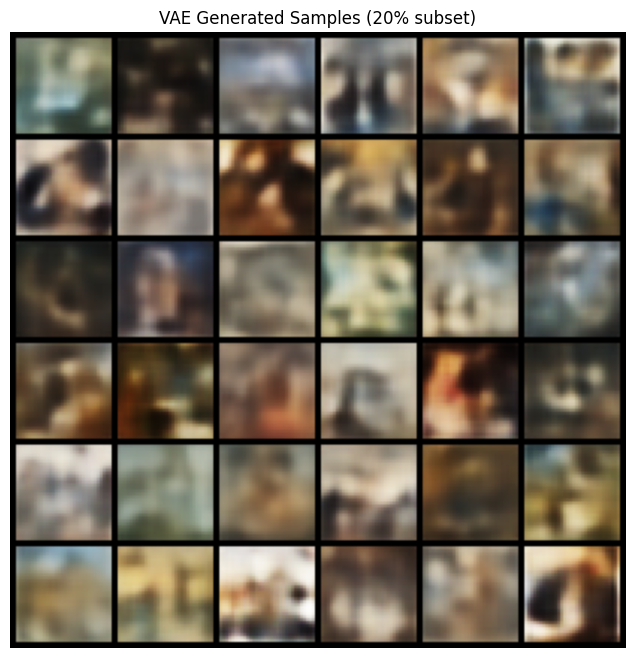

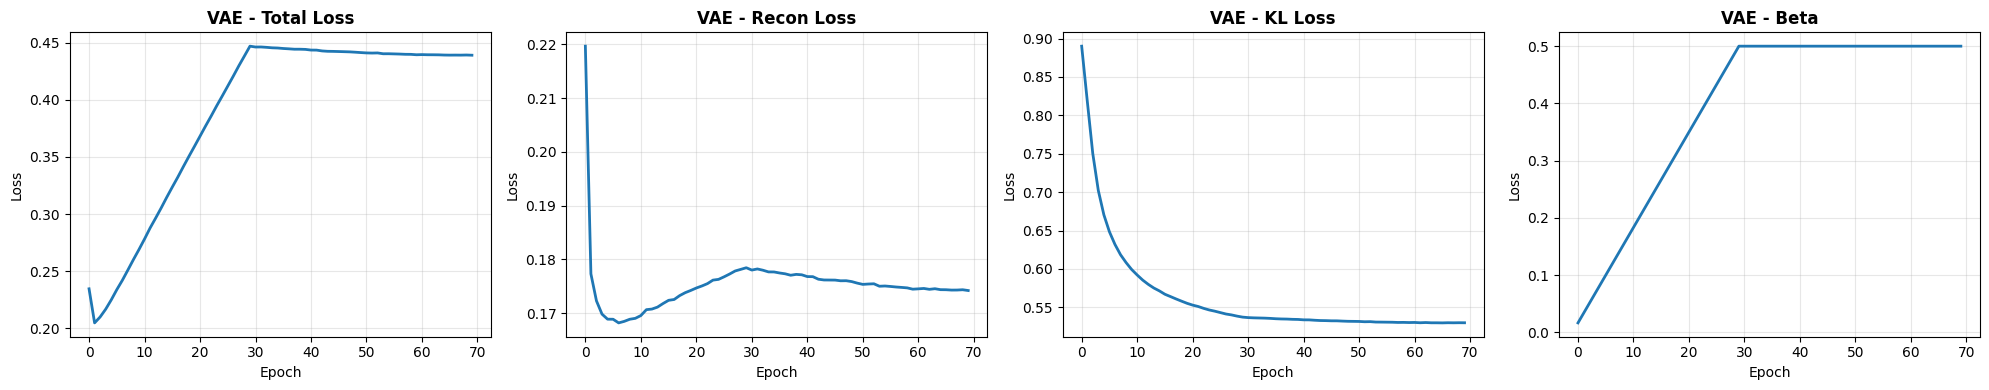

In [69]:
set_seed(SEED)

# Initialize and train VAE model
vae = VAE(latent_dim=128)
print("Training VAE on 20% subset...")
vae_trained, vae_history = train_vae(vae, train_loader_from_csv, num_epochs=70, learning_rate=0.0002)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 VAE samples...")
samples_vae = generate_vae_samples(vae_trained, num_samples=5000, latent_dim=128, batch_size=128)

# Debug: verificar ranges antes da extração de features
print("FAKE:", samples_vae.min().item(), samples_vae.max().item())
print("REAL:", real_samples_phase1.min().item(), real_samples_phase1.max().item())

# Extract features and compute metrics
print("Extracting Inception features from VAE samples...")
vae_gen_features = extract_features_from_tensor(samples_vae, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
vae_fid = calculate_fid(real_features_phase1, vae_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
vae_kid_mean, vae_kid_std = calculate_kid(real_features_phase1, vae_gen_features, n_subsets=50, subset_size=100)

phase1_results['VAE'] = {'FID': vae_fid, 'KID_mean': vae_kid_mean, 'KID_std': vae_kid_std}
print(f"\n✓ VAE Metrics - FID: {vae_fid:.4f} | KID: {vae_kid_mean:.6f} ± {vae_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(samples_vae, title='VAE Generated Samples (20% subset)')
plot_training_history({
    'Total Loss': vae_history['total_loss'],
    'Recon Loss': vae_history['recon_loss'],
    'KL Loss': vae_history['kl_loss'],
    'Beta': vae_history['beta'],
}, model_name='VAE')


cVAE Model

In [ ]:
set_seed(SEED)

# Initialize and train cVAE model
cvae = CVAE(latent_dim=128, num_classes=num_classes)
print("Training cVAE on 20% subset...")
cvae_trained, cvae_history = train_cvae(cvae, train_loader_from_csv, num_epochs=70, learning_rate=0.0002)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 cVAE samples...")
samples_cvae = generate_cvae_samples(cvae_trained, num_samples=5000, latent_dim=128, batch_size=128, num_classes=num_classes)

# Extract features and compute metrics
print("Extracting Inception features from cVAE samples...")
cvae_gen_features = extract_features_from_tensor(samples_cvae, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
cvae_fid = calculate_fid(real_features_phase1, cvae_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
cvae_kid_mean, cvae_kid_std = calculate_kid(real_features_phase1, cvae_gen_features, n_subsets=50, subset_size=100)

phase1_results['cVAE'] = {'FID': cvae_fid, 'KID_mean': cvae_kid_mean, 'KID_std': cvae_kid_std}
print(f"\n✓ cVAE Metrics - FID: {cvae_fid:.4f} | KID: {cvae_kid_mean:.6f} ± {cvae_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(samples_cvae, title='cVAE Generated Samples (20% subset)')
#show_cvae_class_grid(cvae_trained, num_classes=num_classes, samples_per_class=8, latent_dim=128)
plot_training_history({
    'Total Loss': cvae_history['total_loss'],
    'Recon Loss': cvae_history['recon_loss'],
    'KL Loss': cvae_history['kl_loss'],
    'Beta': cvae_history['beta'],
}, model_name='cVAE')

Training cVAE on 20% subset...
cVAE Epoch  10: Total=0.3231, Recon=0.1876, KL=0.5420, β=0.250, LR=1.90e-04
cVAE Epoch  20: Total=0.4470, Recon=0.1892, KL=0.5156, β=0.500, LR=1.63e-04


DCGAN Model

Training DCGAN on 20% subset...
DCGAN Epoch 10: G=2.0453, D=0.9620
DCGAN Epoch 20: G=2.1285, D=0.8465
DCGAN Epoch 30: G=2.1618, D=0.7722
DCGAN Epoch 40: G=2.3218, D=0.7667
DCGAN Epoch 50: G=2.2839, D=0.7443
DCGAN Epoch 60: G=2.1782, D=0.8514
DCGAN Epoch 70: G=2.2524, D=0.7417

Generating 5000 DCGAN samples...
Extracting Inception features from DCGAN samples...
[DEBUG] Samples range BEFORE extractor: min=-0.6019, max=0.9979
Computing FID...
Computing KID (50 subsets of 100 samples)...

✓ DCGAN Metrics - FID: 77.3139 | KID: 0.032131 ± 0.003337



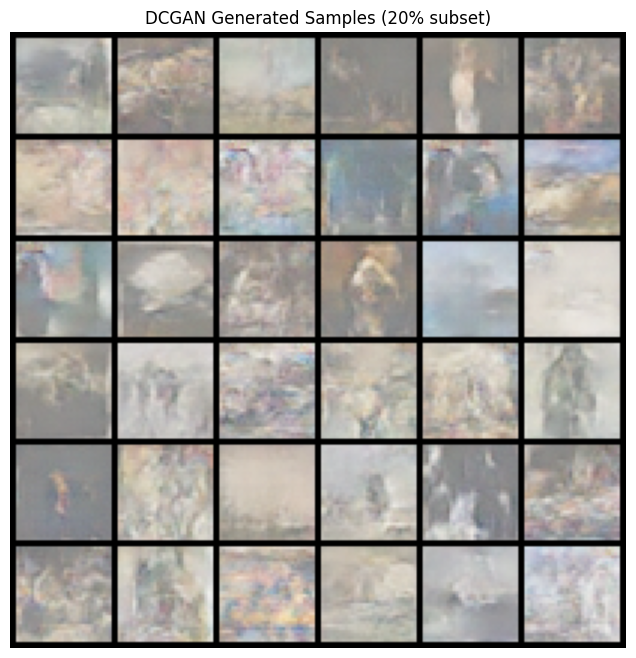

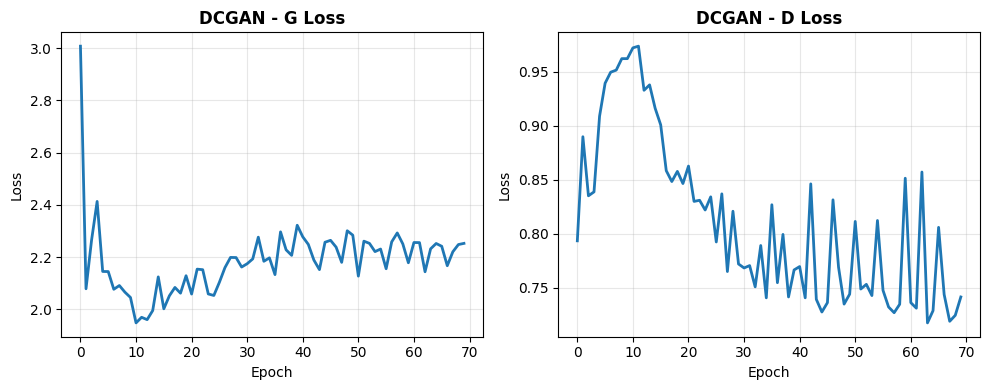

In [ ]:
set_seed(SEED)

# Initialize and train DCGAN models
dcgan_gen = DCGenerator(latent_dim=128)
dcgan_disc = DCDiscriminator()
print("Training DCGAN on 20% subset...")
dcgan_gen, dcgan_disc, dcgan_hist = train_dcgan(dcgan_gen, dcgan_disc, train_loader_from_csv, num_epochs=70, learning_rate=0.0002, latent_dim=128)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 DCGAN samples...")
sample_dcgan = generate_gan_samples(dcgan_gen, num_samples=5000, latent_dim=128, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from DCGAN samples...")
dcgan_gen_features = extract_features_from_tensor(sample_dcgan, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
dcgan_fid = calculate_fid(real_features_phase1, dcgan_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
dcgan_kid_mean, dcgan_kid_std = calculate_kid(real_features_phase1, dcgan_gen_features, n_subsets=50, subset_size=100)

phase1_results['DCGAN'] = {'FID': dcgan_fid, 'KID_mean': dcgan_kid_mean, 'KID_std': dcgan_kid_std}
print(f"\n✓ DCGAN Metrics - FID: {dcgan_fid:.4f} | KID: {dcgan_kid_mean:.6f} ± {dcgan_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(sample_dcgan, title='DCGAN Generated Samples (20% subset)')
plot_training_history({
    'G Loss': dcgan_hist['g_loss'],
    'D Loss': dcgan_hist['d_loss']
}, model_name='DCGAN')

WGAN-GP Model (dizer que experimentámos com spectral norm, mas deu piores resultados (100 de FID))

In [ ]:
set_seed(SEED)

# Initialize and train WGAN-GP models
wgan_gp_gen = WGANGPGenerator(latent_dim=128, img_channels=3)
wgan_gp_critic = WGANGPCritic(img_channels=3)
print("Training WGAN-GP on 20% subset...")
wgan_gp_gen, wgan_gp_critic, wgan_gp_hist = train_wgan(wgan_gp_gen, wgan_gp_critic, train_loader_from_csv, num_epochs=70, latent_dim=128, lambda_gp=10, n_critic=5, lr_gen=1e-4, lr_critic=1e-4)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 WGAN-GP samples...")
sample_wgan_gp = generate_gan_samples(wgan_gp_gen, num_samples=5000, latent_dim=128, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from WGAN-GP samples...")
wgan_gp_gen_features = extract_features_from_tensor(sample_wgan_gp, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
wgan_gp_fid = calculate_fid(real_features_phase1, wgan_gp_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
wgan_gp_kid_mean, wgan_gp_kid_std = calculate_kid(real_features_phase1, wgan_gp_gen_features, n_subsets=50, subset_size=100)

phase1_results['WGAN-GP'] = {'FID': wgan_gp_fid, 'KID_mean': wgan_gp_kid_mean, 'KID_std': wgan_gp_kid_std}
print(f"\n✓ WGAN-GP Metrics - FID: {wgan_gp_fid:.4f} | KID: {wgan_gp_kid_mean:.6f} ± {wgan_gp_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(sample_wgan_gp, title='WGAN-GP Generated Samples (20% subset)')
plot_training_history({
    'G Loss': wgan_gp_hist['g_loss'],
    'C Loss': wgan_gp_hist['c_loss']
}, model_name='WGAN-GP')

Training WGAN-GP on 20% subset...
WGAN-GP Epoch 10: G=0.2365, C=-0.7769
WGAN-GP Epoch 20: G=0.2680, C=-0.8158
WGAN-GP Epoch 30: G=0.4591, C=-0.6326
WGAN-GP Epoch 40: G=0.3682, C=-0.6114
WGAN-GP Epoch 50: G=0.4354, C=-0.5709


KeyboardInterrupt: 

Diffusion Model

Training Diffusion model on 20% subset...
Diffusion Epoch 10: Loss=0.0228
Diffusion Epoch 20: Loss=0.0208
Diffusion Epoch 30: Loss=0.0205
Diffusion Epoch 40: Loss=0.0208
Diffusion Epoch 50: Loss=0.0195
Diffusion Epoch 60: Loss=0.0195
Diffusion Epoch 70: Loss=0.0195

Generating 5000 Diffusion samples...
Extracting Inception features from Diffusion samples...
[DEBUG] Samples range BEFORE extractor: min=-0.2837, max=1.0000
Computing FID...
Computing KID (50 subsets of 100 samples)...

✓ Diffusion Metrics - FID: 42.7640 | KID: 0.017374 ± 0.002261



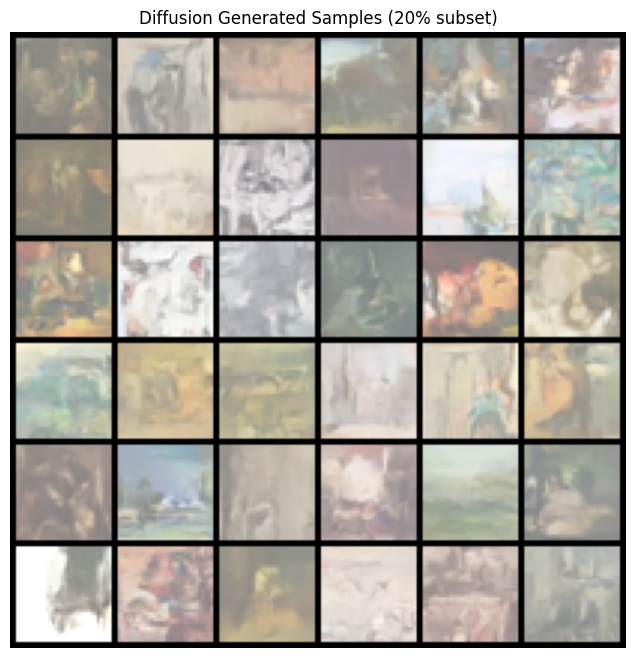

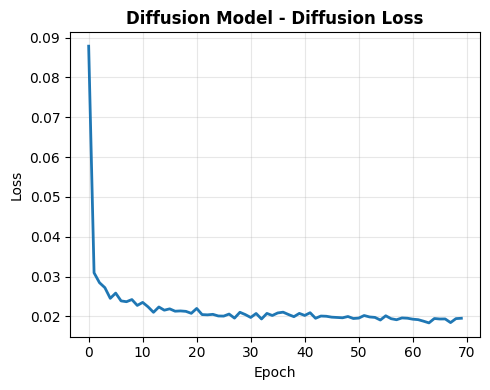

In [ ]:
set_seed(SEED)

# Initialize and train Diffusion model
diffusion = SimpleUNet(img_channels=3)
print("Training Diffusion model on 20% subset...")
diffusion_trained, diffusion_hist = train_diffusion(diffusion, train_loader_from_csv, num_epochs=70, learning_rate=0.0002, num_steps=1000)
schedule = DiffusionSchedule(num_steps=1000).to(DEVICE)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 Diffusion samples...")
sample_diffusion = generate_diffusion_samples(diffusion_trained, schedule, num_samples=5000, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from Diffusion samples...")
diffusion_gen_features = extract_features_from_tensor(sample_diffusion, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
diffusion_fid = calculate_fid(real_features_phase1, diffusion_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
diffusion_kid_mean, diffusion_kid_std = calculate_kid(real_features_phase1, diffusion_gen_features, n_subsets=50, subset_size=100)

phase1_results['Diffusion'] = {'FID': diffusion_fid, 'KID_mean': diffusion_kid_mean, 'KID_std': diffusion_kid_std}
print(f"\n✓ Diffusion Metrics - FID: {diffusion_fid:.4f} | KID: {diffusion_kid_mean:.6f} ± {diffusion_kid_std:.6f}\n")

# Visualize generated samples and training history (convert [-1,1] → [0,1] for display)
show_generated_samples(sample_diffusion, title='Diffusion Generated Samples (20% subset)')
plot_training_history({'Diffusion Loss': diffusion_hist['loss']}, model_name='Diffusion Model')

## Phase 1: Results Summary

Compare all trained models' FID and KID metrics computed on the 20% subset.


In [ ]:
print("\n" + "="*70)
print("PHASE 1 RESULTS SUMMARY")
print("="*70)

if phase1_results:
    # Create results dataframe
    results_df = pd.DataFrame([
        {'Model': model, **metrics}
        for model, metrics in phase1_results.items()
    ])
    print(results_df.to_string(index=False))
    
    # Identify best model
    best_model_name = min(phase1_results, key=lambda m: phase1_results[m]['FID'])
    best_fid = phase1_results[best_model_name]['FID']
    print(f"\n🏆 BEST MODEL (lowest FID): {best_model_name} with FID = {best_fid:.4f}")
    print(f"\n→ Next: Retrain {best_model_name} on 100% dataset in Phase 2 with ≥10 random seeds")
    print("="*70)
else:
    print("\nNo model results yet. Run the VAE, cVAE, DCGAN, WGAN-GP, and Diffusion training cells first.")
    print("="*70)

## Phase 2: Final Evaluation on 100% Dataset

**Objective:** Retrain the best model (selected from Phase 1) on the full dataset with ≥10 random seeds for robust FID/KID statistics.

**Dataloader:** `train_loader` (100% of training data)

**Edit the code below** to use your best model:
- Replace the placeholder training block with `train_vae(...)`, `train_cvae(...)`, `train_dcgan(...)`, `train_wgan(...)`, or `train_diffusion(...)` based on Phase 1 results
- Use the matching sample generation function for the chosen model
- Output: Mean ± Std of FID and KID across all seeds

In [ ]:
# Phase 2: Retrain best model from Phase 1 on 100% dataset with 10 random seeds
# 
# CUSTOMIZE FOR YOUR BEST MODEL:
# - If DCGAN: replace train_vae(...) with train_dcgan(...) and generate_vae_samples(...) with generate_dcgan_samples(...)
# - If WGAN-GP: replace train_vae(...) with train_wgan_gp(...) and generate_vae_samples(...) with generate_wgan_gp_samples(...)
# - If Diffusion: replace train_vae(...) with train_diffusion(...) and generate_vae_samples(...) with generate_diffusion_samples(...)

results = {}
for seed in range(10):  # ≥10 random seeds
    set_seed(seed)
    print(f"\n=== Seed {seed} ===")
    
    # Retrain best model on FULL dataset
    print("Retraining on 100% dataset...")
    diffusion_schedule_phase2 = DiffusionSchedule(latent_dim=128, img_channels=3)
    diffusion_model_phase2 = DiffusionSchedule(latent_dim=128, img_channels=3)
    best_model, _, hist = train_diffusion(diffusion_schedule_phase2, diffusion_model_phase2, train_loader, num_epochs=70, learning_rate=0.0002, latent_dim=128)
    
    # Create feature extractor for this seed
    feature_extractor = InceptionFeatureExtractor(device=DEVICE)
    # Generate 5000 samples and get real samples
    print("Generating 5000 samples...")
    gen_samples = generate_gan_samples(best_model, num_samples=5000, latent_dim=128, batch_size=BATCH_SIZE)
    print("Extracting features...")
    real_samples = get_real_samples(train_loader, num_samples=5000)
    gen_features = extract_features_from_tensor(gen_samples, feature_extractor, DEVICE, batch_size=128)
    real_features = extract_features_from_tensor(real_samples, feature_extractor, DEVICE, batch_size=128)
    
    # Compute metrics
    fid = calculate_fid(real_features, gen_features)
    kid_mean, kid_std = calculate_kid(real_features, gen_features, n_subsets=50, subset_size=100)
    
    results[seed] = {'FID': fid, 'KID_mean': kid_mean, 'KID_std': kid_std}
    print(f"  FID: {fid:8.4f} | KID: {kid_mean:.6f}±{kid_std:.6f}")

# Aggregate and display results
print("\n" + "="*70)
print("PHASE 2 RESULTS: FINAL METRICS ACROSS 10 SEEDS")
print("="*70)

fid_values = [results[s]['FID'] for s in sorted(results.keys())]
kid_means = [results[s]['KID_mean'] for s in sorted(results.keys())]

print(f"\nFID  : {np.mean(fid_values):.4f} ± {np.std(fid_values):.4f}")
print(f"KID  : {np.mean(kid_means):.6f} ± {np.std(kid_means):.6f}")
print("\nPer-seed results:")
for seed in sorted(results.keys()):
    print(f"  Seed {seed:2d}: FID={results[seed]['FID']:8.4f} | KID={results[seed]['KID_mean']:.6f}±{results[seed]['KID_std']:.6f}")
print("="*70)

---

# Project Deliverables & Summary

## What You Have Built

This notebook provides a **complete generative modeling pipeline** for ArtBench-10:

### Components:
1. **Data Loading** (STEP 1-2): Load 32×32 art images with preprocessing
2. **Model Implementations** (STEP 3): Five generative architectures
   - VAE: Probabilistic latent space learning
   - cVAE: Label-conditioned probabilistic generation
   - DCGAN: Adversarial image generation
   - WGAN-GP: Wasserstein adversarial generation with gradient penalty
   - Diffusion: Iterative denoising process
3. **Training Infrastructure**: Optimized loops with loss tracking
4. **Evaluation Metrics**: FID & KID for quantitative assessment
5. **Sample Generation**: Inference pipelines for all models
6. **Utilities**: Checkpointing, visualization, reporting

---

## Project Workflow

### Phase 1️⃣ - Development (≈2-3 hours on 20% subset)
```
Load Data → Train 5 Models → Generate Samples → Quick Evaluation → Select Best
```
- Goal: Find best hyperparameters and architecture
- Dataset: 20% = ~1000 training samples
- Output: Trained checkpoint of best model + loss curves

### Phase 2️⃣ - Production (≈8-12 hours on 100% dataset)
```
Retrain Best Model (10+ seeds) → Collect Metrics → Aggregate Results → Create Report
```
- Goal: Get statistically robust FID/KID scores
- Dataset: 100% = ~5000 training samples
- Output: Mean ± Std metrics + visualization

## Expected Results (Benchmark from Literature)

- **VAE / cVAE**: FID ~80-120 (stable training, softer images, cVAE gives class control)
- **DCGAN / WGAN-GP**: FID ~40-70 (sharper images, can still suffer from instability or limited diversity)
- **Diffusion**: FID ~30-50 (best quality, slowest generation)

---

## Next Steps After Training

1. **Visualize Training Curves**: Use `plot_training_history()` to inspect convergence
2. **Generate Sample Grid**: Use `show_generated_samples()` for visual inspection
3. **Compare Models**: Build results table showing FID/KID across all trained models
4. **Write Report**: Document findings and explain why the chosen model performed best
5. **Save Artifacts**: Checkpoints, generated samples, metrics CSV